In [1]:
from abc import abstractmethod
from abc import ABC
from typing import Any
import numpy as np
from numpy.typing import NDArray


class Optimizer(ABC):
  def __init__(self, *, lr: float = 0.01):
    self._lr = lr

  @property
  def lr(self) -> float:
    return self._lr

  @lr.setter
  def lr(self, value: float):
    assert value > 0, "lr은 0보다 커야 합니다."
    self._lr = value

  @abstractmethod
  def step(self, X: NDArray[Any], dX: NDArray[Any]): ...


class SGD(Optimizer):
  def step(self, X: NDArray[Any], dX: NDArray[Any]):
    X -= dX * self.lr

class Adam(Optimizer):
  def __init__(self, *, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    super().__init__(lr=lr)
    self.beta1 = beta1
    self.beta2 = beta2
    self.eps = eps

    self.t = 0  # 스텝 카운터
    self.m = {}  # 1차 모멘트
    self.v = {}  # 2차 모멘트

  def step(self, X: NDArray[Any], dX: NDArray[Any]):
    # 파라미터 식별자로 id 사용
    param_id = id(X)

    # 처음 보는 파라미터면 초기화
    if param_id not in self.m:
      self.m[param_id] = np.zeros_like(X)
      self.v[param_id] = np.zeros_like(X)

    self.t += 1

    # 모멘트 업데이트
    self.m[param_id] = self.beta1 * self.m[param_id] + (1 - self.beta1) * dX
    self.v[param_id] = self.beta2 * self.v[param_id] + (1 - self.beta2) * dX**2

    # Bias correction
    m_hat = self.m[param_id] / (1 - self.beta1**self.t)
    v_hat = self.v[param_id] / (1 - self.beta2**self.t)

    # 업데이트
    X -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# ------------------------------------------------------------


class Differentiable(ABC):
  @abstractmethod
  def forward(self, *args, **kwargs) -> Any: ...

  @abstractmethod
  def backward(self, *args, **kwargs) -> Any: ...


class Module(Differentiable):
  @abstractmethod
  def forward(self, X: NDArray[Any]) -> NDArray[Any]: ...

  @abstractmethod
  def backward(self, delta: NDArray[Any]) -> NDArray[Any]: ...

  @abstractmethod
  def optimize(self, optimizer: Optimizer): ...

  @abstractmethod
  def format(self, indent: int = 0) -> str: ...

  def __str__(self):
    return self.format()

  def __repr__(self):
    return self.format()


class Linear(Module):
  """완전연결(Linear) 레이어.

  입력 텐서 `X`의 마지막 차원을 `in_features`로 보고,
  각 샘플에 대해 `out_features` 차원의 출력을 생성한다.

  Attributes:
      in_features: 입력 특성 수.
      out_features: 출력 특성 수.
      W: 가중치 행렬. shape `(out_features, in_features)`.
      b: 편향 벡터. shape `(out_features,)`.
      dW: 가중치 그래디언트. `backward()` 호출 후 설정되며,
          옵티마이저(예: SGD)가 `W`를 갱신할 때 사용된다.
      db: 편향 그래디언트. `backward()` 호출 후 설정되며,
          옵티마이저(예: SGD)가 `b`를 갱신할 때 사용된다.
  """

  def __init__(self, in_features: int, out_features: int):
    """선형 레이어를 초기화한다.

    Args:
        in_features: 입력 특성 수.
        out_features: 출력 특성 수.
    """

    self.in_features = in_features
    self.out_features = out_features

    self._cache_X: NDArray[Any] | None = None

    self.W = np.random.randn(self.out_features, self.in_features)
    self.b = np.zeros(self.out_features)
    self.dW: NDArray[Any] | None = None
    self.db: NDArray[Any] | None = None

  def forward(self, X: NDArray[Any]):
    """순전파를 수행한다.

    Args:
        X: 입력 배치. shape `(N, in_features)`.

    Returns:
        선형 변환 결과. shape `(N, out_features)`.

    Notes:
        역전파 계산을 위해 최신 입력 `X`를 내부 캐시에 저장한다.
    """

    self._cache_X = X

    return X @ self.W.T + self.b

  def backward(self, delta: NDArray[Any]):
    """역전파를 수행해 입력/파라미터 그래디언트를 계산한다.

    Args:
        delta: 출력에 대한 손실의 편미분(`∂L/∂Y`).
            shape `(N, out_features)`.

    Returns:
        입력에 대한 손실의 편미분(`∂L/∂X`).
        shape `(N, in_features)`.

    Notes:
        계산된 `dW`, `db`는 파라미터 최적화(optimization)를 위해 저장되며,
        반환되는 `dX`는 이전 레이어로 그래디언트를 전달하는 역전파에 사용된다.

    Raises:
        AssertionError: `forward()`가 먼저 호출되지 않아 입력 캐시가 비어 있는 경우.
    """

    X = self._cache_X
    assert X is not None, "forward 이전에 backward는 호출할 수 없습니다."

    db = delta.sum(axis=0)
    dW = delta.T @ X
    dX = delta @ self.W

    self.dW = dW
    self.db = db

    return dX

  def optimize(self, optimizer: Optimizer):
    assert self.dW is not None and self.db is not None, (
      "optimize를 backward 하기 전에 할 수 없습니다."
    )

    optimizer.step(self.W, self.dW)
    optimizer.step(self.b, self.db)

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}{type(self).__name__}(in_features={self.in_features}, out_features={self.out_features})"


class Sigmoid(Module):
  """시그모이드 활성화 함수 레이어."""

  def __init__(self):
    """Sigmoid 레이어를 초기화한다."""

    self._cache_X: NDArray[Any] | None = None

  def forward(self, X: NDArray[Any]):
    """순전파로 시그모이드 출력을 계산한다."""

    self._cache_X = X

    return 1 / (1 + np.exp(-X))

  def backward(self, delta: NDArray[Any]):
    """역전파로 입력 그래디언트(`∂L/∂X`)를 계산한다."""

    X = self._cache_X
    assert X is not None, "forward 이전에 backward는 호출할 수 없습니다."

    dX = delta * self.forward(X) * (1 - self.forward(X))

    return dX

  def optimize(self, optimizer: Optimizer):
    pass

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}{type(self).__name__}()"


class ReLU(Module):
  def __init__(self):
    self._cache_X: NDArray[Any] | None = None

  def forward(self, X: NDArray[Any]):
    self._cache_X = X

    return np.maximum(0, X)

  def backward(self, delta: NDArray[Any]):
    X = self._cache_X
    assert X is not None, "forward 이전에 backward는 호출할 수 없습니다."

    dX = delta * (X > 0).astype(np.float32)
    return dX

  def optimize(self, optimizer: Optimizer):
    pass

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}{type(self).__name__}()"


class Sequential(Module):
  """여러 `Module`을 순차적으로 연결한 컨테이너."""

  def __init__(self, modules: list[Module]):
    """순차 모델을 초기화한다.

    Args:
        modules: 순전파 순서대로 실행할 모듈 목록.
    """

    assert len(modules) > 0, "비어 있는 Sequential은 선언할 수 없습니다."

    self.modules = modules
    self._cache_X: NDArray[Any] | None = None

  def forward(self, X: NDArray[Any]):
    """모든 하위 모듈에 대해 순전파를 차례로 수행한다."""

    self._cache_X = X

    x = X
    for module in self.modules:
      x = module.forward(x)

    return x

  def backward(self, delta: NDArray[Any]):
    """모든 하위 모듈에 대해 역전파를 역순으로 수행한다."""

    dX = delta
    for module in reversed(self.modules):
      dX = module.backward(dX)

    return dX

  def optimize(self, optimizer: Optimizer):
    """모든 하위 모듈의 파라미터를 옵티마이저로 갱신한다."""

    for module in self.modules:
      module.optimize(optimizer)

  def format(self, indent: int = 0) -> str:
    indent_str = "  " * indent

    lines = [f"{indent_str}{type(self).__name__}("]
    for module in self.modules:
      lines.append(f"{module.format(indent + 1)},")
    lines.append(f"{indent_str})")

    return "\n".join(lines)


# ------------------------------------------------------------


class Loss(Differentiable):
  @abstractmethod
  def forward(self, Y: NDArray[Any], T: NDArray[Any]) -> float: ...

  @abstractmethod
  def backward(self) -> NDArray[Any]: ...


class CrossEntropyLoss(Loss):
  def __init__(self):
    self._cache_probs: NDArray[Any] | None = None
    self._cache_T: NDArray[Any] | None = None

  def forward(self, Y: NDArray[Any], T: NDArray[Any]) -> float:
    """
    Y: (N, 10)  - 모델 출력(logits)
    T: (N, )    - 정답 인덱스
    """

    assert Y.shape[0] == T.shape[0], "Y와 T의 갯수가 다릅니다."

    N: int = int(Y.shape[0])

    max_by_row: NDArray[np.float64] = np.max(Y, axis=1, keepdims=True)  # 열벡터 (N, 1)
    shifted = Y - max_by_row  # <= 0, (N, 10)

    exp_shifted = np.exp(shifted)  # <= 1, 열벡터 (N, 10)
    sum_by_row: NDArray[Any] = exp_shifted.sum(axis=1, keepdims=True)  # 열벡터 (N, 1)
    probs: NDArray[Any] = exp_shifted / sum_by_row  # [0, 1], (N, 10)
    log_probs: NDArray[Any] = np.log(
      probs[np.arange(N), T] + 1e-9
    )  # log 0 방지, (N,), log[0, 1] -> (-inf, 0]

    self._cache_probs = probs
    self._cache_T = T

    return float(-log_probs.mean())  # [0, inf)

  def backward(self) -> NDArray[Any]:
    probs = self._cache_probs
    T = self._cache_T
    assert probs is not None and T is not None, "forward 이전에 backward는 호출할 수 없습니다."

    N: int = int(probs.shape[0])
    dY = probs.copy()
    dY[np.arange(N), T] -= 1.0
    dY /= N

    return dY


In [2]:
!uv add --dev scikit-learn
!uv add matplotlib
!uv add tqdm
!uv add ipywidgets

Resolved 44 packages in 9ms
Audited 42 packages in 8ms
Resolved 44 packages in 3ms
Audited 33 packages in 0.52ms
Resolved 44 packages in 3ms
Audited 33 packages in 0.75ms
Resolved 44 packages in 3ms
Audited 33 packages in 0.47ms


In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser='liac-arff')
mnist

{'data': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(70000, 784)),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object),
 'frame': None,
 'categories': {},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',
  'pixel45',
  'pixel46

In [4]:
X = mnist.data.astype(np.float32) / 255.0
T = mnist.target.astype(np.int64)

print(f'{X.shape=}, {X.dtype=}, {np.max(X)}, {T.shape=}, {T.dtype=}')

X.shape=(70000, 784), X.dtype=dtype('float32'), 1.0, T.shape=(70000,), T.dtype=dtype('int64')


In [5]:
X_train, X_test = X[:60000], X[60000:]
T_train, T_test = T[:60000], T[60000:]

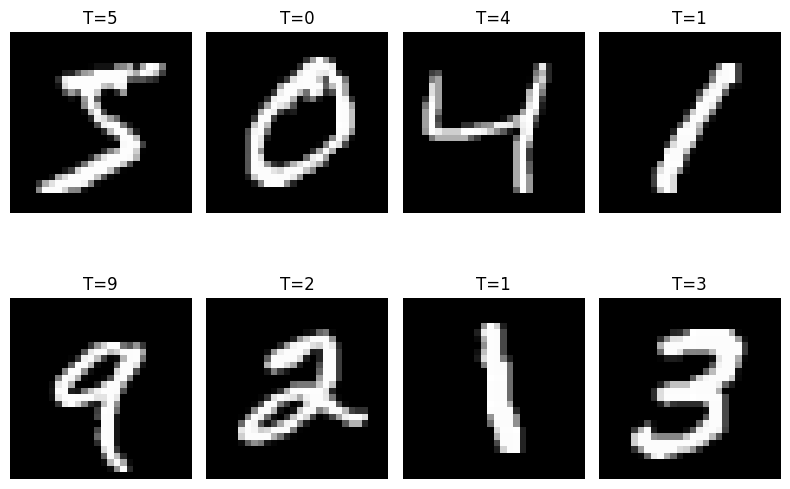

In [6]:
import matplotlib.pyplot as plt

num_samples = 8
indices = np.arange(num_samples)

fig, axes = plt.subplots(2, 4, figsize=(8, 6))
axes = axes.ravel()

for i, idx in enumerate(indices):
  axes[i].imshow(X[idx].reshape(28, 28), cmap="gray")
  axes[i].set_title(f"T={T[idx]}")
  axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
module = Sequential(
  [
    Linear(784, 256),
    ReLU(),
    Linear(256, 64),
    ReLU(),
    Linear(64, 10),
  ]
)

module

Sequential(
  Linear(in_features=784, out_features=256),
  ReLU(),
  Linear(in_features=256, out_features=64),
  ReLU(),
  Linear(in_features=64, out_features=10),
)

In [8]:
X_train.shape, T_train.shape

((60000, 784), (60000,))

In [9]:
N_train = X_train.shape[0]
N_test = X_test.shape[0]

N_train, N_test

(60000, 10000)

In [10]:
optimizer = Adam(lr=0.001)
loss_fn = CrossEntropyLoss()

optimizer, loss_fn

(<__main__.Adam at 0x11762c6e0>, <__main__.CrossEntropyLoss at 0x11762cad0>)

In [11]:
from tqdm.notebook import tqdm


def iterate_minibatches(X, T, batch_size, *, shuffle=False):
  N = X.shape[0]
  indices = np.random.permutation(N) if shuffle else np.arange(N)

  for start in range(0, N, batch_size):
    batch_idx = indices[start : start + batch_size]
    yield X[batch_idx], T[batch_idx]


def run_epoch(module, loss_fn, X, T, *, batch_size, training, optimizer=None):
  N = X.shape[0]
  total_loss = 0.0
  total_correct = 0
  steps = 0

  total_steps = (N + batch_size - 1) // batch_size
  batches = iterate_minibatches(X, T, batch_size, shuffle=training)

  for x, t in tqdm(batches, total=total_steps, leave=False):
    y = module.forward(x)
    loss = loss_fn.forward(y, t)

    if training:
      assert optimizer is not None
      dy = loss_fn.backward()
      module.backward(dy)
      module.optimize(optimizer)

    pred = np.argmax(y, axis=1)
    total_correct += int((pred == t).sum())
    total_loss += loss
    steps += 1

  return {
    "loss": total_loss / steps,
    "accuracy": total_correct / N,
  }


def train(module, optimizer, loss_fn, X_train, T_train, X_test, T_test, *, epochs=20, batch_size=64, test_batch_size=256):
  for epoch in range(1, epochs + 1):
    train_metrics = run_epoch(
      module,
      loss_fn,
      X_train,
      T_train,
      batch_size=batch_size,
      training=True,
      optimizer=optimizer,
    )
    test_metrics = run_epoch(
      module,
      loss_fn,
      X_test,
      T_test,
      batch_size=test_batch_size,
      training=False,
    )

    print(
      f"epoch {epoch}/{epochs} | "
      f"train_loss={train_metrics['loss']:.4f} | "
      f"train_acc={train_metrics['accuracy']:.4%} | "
      f"test_loss={test_metrics['loss']:.4f} | "
      f"test_acc={test_metrics['accuracy']:.4%}"
    )


train(
  module,
  optimizer,
  loss_fn,
  X_train,
  T_train,
  X_test,
  T_test,
  epochs=100,
  batch_size=64,
  test_batch_size=256,
)

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

epoch 1/100 | train_loss=4.6778 | train_acc=76.3000% | test_loss=2.7750 | test_acc=85.6000%


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

epoch 99/100 | train_loss=0.0120 | train_acc=99.7867% | test_loss=0.5160 | test_acc=96.3400%


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

epoch 100/100 | train_loss=0.0088 | train_acc=99.8500% | test_loss=0.5465 | test_acc=96.2500%


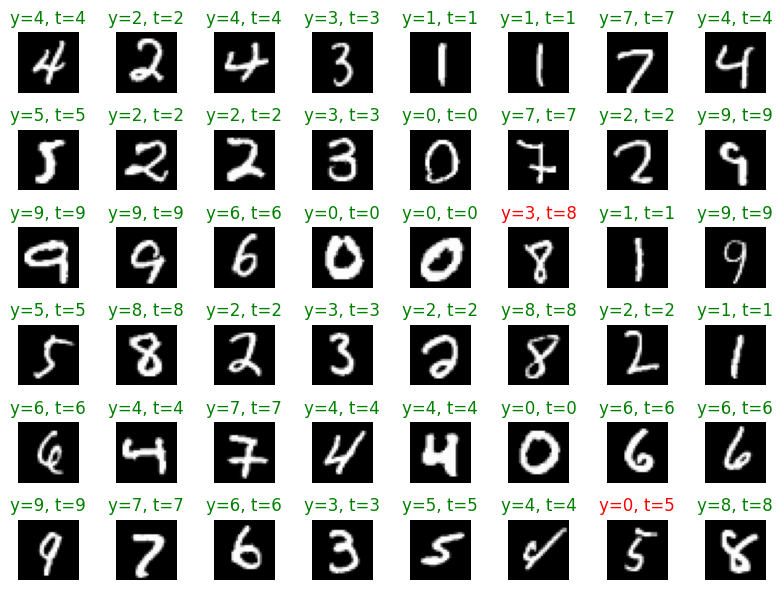

In [20]:
num_samples = 48
indices = np.random.choice(X_test.shape[0], size=num_samples, replace=False)

x_samples = X_test[indices]
t_samples = T_test[indices]
logits = module.forward(x_samples)
preds = np.argmax(logits, axis=1)

fig, axes = plt.subplots(6, 8, figsize=(8, 6))
axes = axes.ravel()

for i, ax in enumerate(axes):
  ax.imshow(x_samples[i].reshape(28, 28), cmap="gray")
  is_correct = preds[i] == t_samples[i]
  ax.set_title(f"y={preds[i]}, t={t_samples[i]}", color=("green" if is_correct else "red"))
  ax.axis("off")

plt.tight_layout()
plt.show()